In [1]:
source("Main.R")
source("Utilities.R")
source("Conf.R")
library(ggplot2)

corrplot 0.95 loaded


Attaching package: ‘pls’


The following object is masked from ‘package:corrplot’:

    corrplot


The following object is masked from ‘package:stats’:

    loadings



Attaching package: ‘reshape2’


The following objects are masked from ‘package:data.table’:

    dcast, melt


Welcome! Want to learn more? See two factoextra-related books at https://goo.gl/ve3WBa

Loading required package: cluster

Loading required package: rpart


Attaching package: ‘ggpubr’


The following object is masked from ‘package:cowplot’:

    get_legend




In [5]:
options(repr.plot.width = 10, repr.plot.height = 8)

plotTwoConditions <- function(cond1, cond2, cond1_res, cond2_res){
 
    cond1_res[cond1_res$fdr<0.1,"percent_change"] = 0
    cond2_res[cond2_res$fdr<0.1,"percent_change"] = 0

    rownames(cond1_res) = paste0(cond1_res$target,"_",cond1_res$feature)
    rownames(cond2_res) = paste0(cond2_res$target,"_",cond2_res$feature)

    commonRows=rownames(cond1_res)[rownames(cond1_res) %in% rownames(cond2_res)]


    cond1_res = cond1_res[commonRows,]
    cond2_res = cond2_res[commonRows,]


    # subset data
    df <- data.frame(
      x = cond1_res$percent_change[1:500000],
      y = cond2_res$percent_change[1:500000]
    )
    
    # compute Pearson correlation
    corr <- cor(df$x, df$y, method = "pearson", use = "complete.obs")

    options(repr.plot.width = 10, repr.plot.height = 8)
    print(ggplot(df, aes(x = x, y = y)) +
      geom_point(alpha = 0.3, size = 0.5) +
      geom_hline(yintercept = 0, color = "gray60") +
      geom_vline(xintercept = 0, color = "gray60") +
      geom_abline(intercept = 0, slope = 1, color = "red", linetype = "dashed", size = 1) +
      coord_cartesian(xlim = c(-1, 1), ylim = c(-1, 1)) +
      annotate("text", x = -0.9, y = 0.9,
               label = paste0("Pearson r = ", round(corr, 3)),
               hjust = 0, size = 5) +
      labs(
        x = paste0("Effect size under ", cond1),
        y = paste0("Effect size under ", cond2)
      ) +
      theme_minimal(base_size = 20))

    
}


In [3]:
cond1_res=read.csv(paste0("./DMSO/DMSO_res.csv"))
cond2_res=read.csv(paste0("./DMSO_round2/DMSO_round2_res.csv"))


Warning message:
“Removed 1103 rows containing missing values or values outside the scale range
(`geom_point()`).”


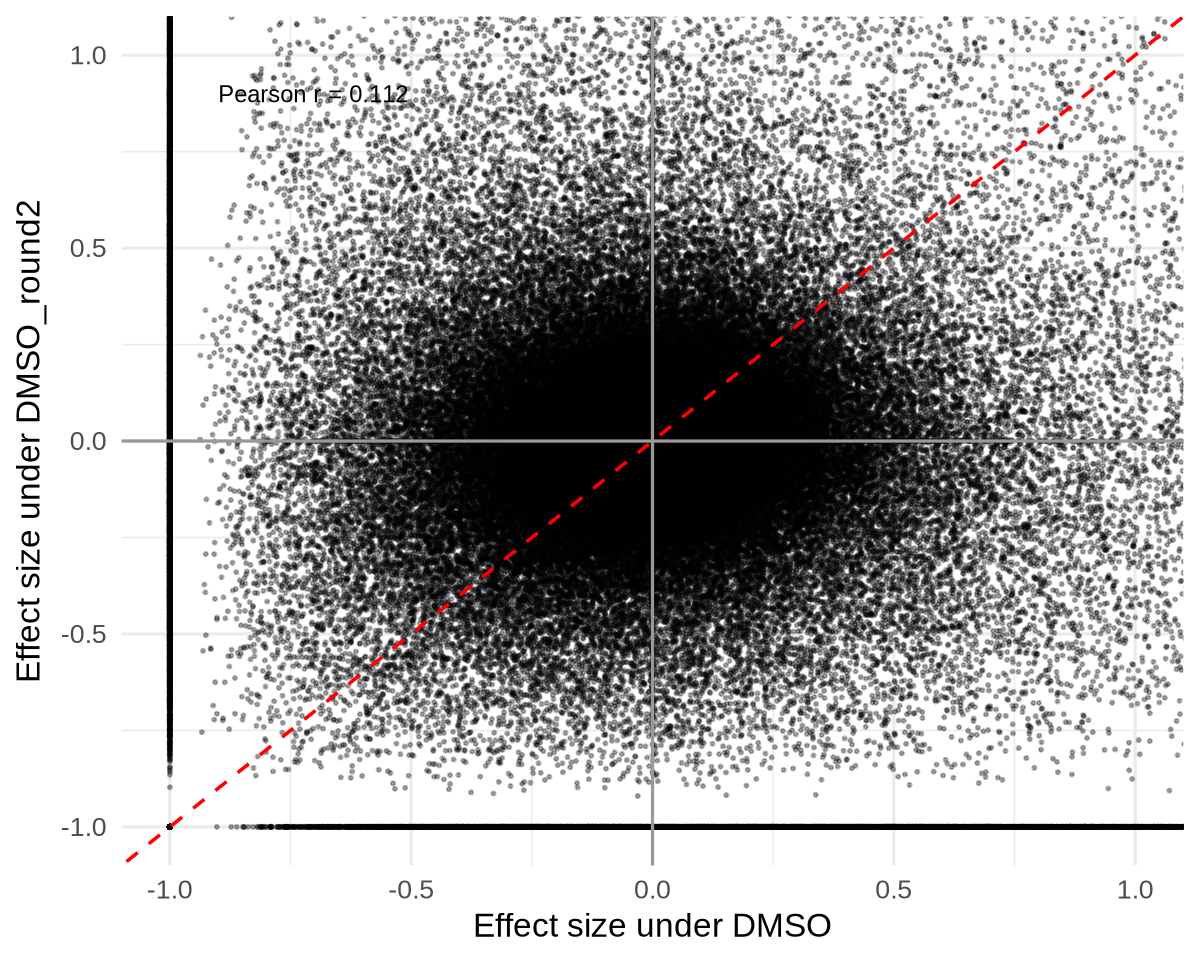

In [6]:
plotTwoConditions(cond1="DMSO", cond2="DMSO_round2", cond1_res, cond2_res)

In [ ]:
dmso_fc_zeroed = read.csv("dmso_fc_zeroed.csv",
                          row.names = 1)
dmso_round2_fc_zeroed = read.csv("dmso_round2_fc_zeroed.csv",
                                 row.names = 1)

In [ ]:
dmso_fc_zeroed[dmso_fc_zeroed > 0]=1
dmso_fc_zeroed[dmso_fc_zeroed < 0]= -1

In [ ]:
k <-  pheatmap(
      dmso_fc_zeroed,
      number_color = "black",
      fontsize_col=1,fontsize_row=1,
      clustering_method = "ward.D2",
      color = colorRampPalette(colorCode)(100))

In [ ]:
head(DMSO_round2)

In [ ]:
head(DMSO)

In [ ]:
read.csv()



In [ ]:
cor(DMSO_r1_FC_melted$DMSO_r1_value, DMSO_r1_FC_melted$DMSO_r2_value)

In [ ]:
cor(DMSO_r1_bc_FC_melted$DMSO_r1_value[1:500000],DMSO_r1_bc_FC_melted$DMSO_r2_value[1:500000])

In [ ]:
plot(DMSO_r1_bc_FC_melted$DMSO_r1_value[1:500000], 
     DMSO_r1_bc_FC_melted$DMSO_r2_value[1:500000], xlim=c(-1,10),ylim=c(-1,10))

In [ ]:
head(DMSO_r1_bc_FC_melted)